In [1]:
import phd_parser as pp
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

In [2]:
MOCK_FILE_PATH = Path(r"..\tests\massspec\2026-03-26_sk1002_02-react.asc")
MOCK_FILE_PATH.absolute()

tos_start = pd.Timestamp("2026-03-26 14:00:00", tz="Europe/Amsterdam")

In [3]:
ms_raw = pp.massspec.MSData.from_quadstar_asc(MOCK_FILE_PATH, tos_start=tos_start)

In [5]:
ms = ms_raw.select_tos_range(0, 7.5 * 3600)

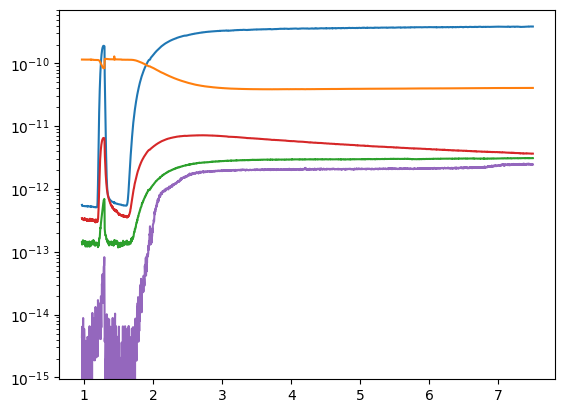

In [17]:
fig, ax = plt.subplots()
ax.plot(ms.tos / 3600, ms.get_trace(mz = 2))
ax.plot(ms.tos / 3600, ms.get_trace(mz = 4))
ax.plot(ms.tos / 3600, ms.get_trace(mz = 16))
ax.plot(ms.tos / 3600, ms.get_trace(mz = 18))
ax.plot(ms.tos / 3600, ms.get_trace(mz = 28))

ax.set_yscale("log")

In [18]:
path_drifts = Path(r"C:\Users\jsommer1\OneDrive\02_Projects\[UniZeug]\2024_PhD\01_Project\21_Experiments\01_raw\Box5_Spectrocsopy")
path_experiment = path_drifts / "2026-03-26_SK1002"
path_ir = path_experiment / "omnic" / "02_Reaction"

ir_raw = pp.infrared.IRData.from_omnic_spa(path_ir,tos_start=tos_start)

Raw tos_start from metadata: Timestamp('2026-03-26 14:00:00+0100', tz='Europe/Amsterdam')


In [19]:
ir = ir_raw.select_wavenumber_range(1000, None).smooth_moving(window_size=5)

In [20]:
ir_ = ir.average_scans(20, tos_method="first")

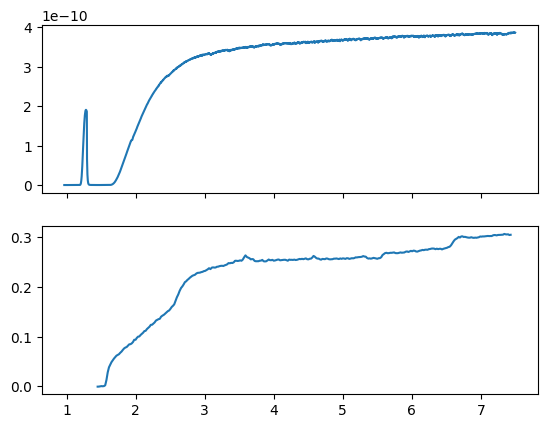

In [21]:
fig, ax = plt.subplots(2, 1, sharex=True)

ax[0].plot(ms.tos / 3600, ms.get_trace(2))

ax[1].plot(ir_.tos / 3600, ir_.get_evolution(1620))